**CAPSTONE PROJECT MIND CHECK**

Please fill out:
* Student names: 
* Student pace:  **PART TIME**
* Scheduled project review date/time: **18/11/2024**
* Instructor name: ****


**1.  Introduction**

Mental health has become an urgent public health concern across the globe, and Kenya is no exception. Approximately 25% of outpatients and 40% of inpatients in Kenyan healthcare facilities are affected by mental health conditions, according to the Kenyan National Commission of Human Rights. Depression, substance abuse, stress, and anxiety disorders are among the most commonly diagnosed mental health issues in hospital settings, a reflection of an alarming national trend. The situation is compounded by limited data on mental health, neurological issues, and substance use (MNS) in Kenya, making it challenging to address these concerns effectively.


The World Health Organization (WHO) ranks Kenya among the African nations with the highest depression rates, with estimates suggesting that around two million Kenyans are impacted by depression alone. Disturbingly, one in four Kenyans will experience a mental health disorder at some point in their lives.


Given the urgent need to address mental health concerns, this project aims to leverage artificial intelligence to identify and analyze mental health indicators within social media text.

By capturing and analyzing patterns of mental health issues expressed in public discourse, the project seeks to provide insights that can inform policymakers, healthcare providers, and support systems. In doing so, it contributes to a broader understanding of mental health in Kenya and aligns with the national objective of prioritizing mental well-being.

**Problem Statement**








Mental health issues like depression, anxiety, and suicidal tendencies often go unnoticed in daily conversations, especially in online forums, social media posts, or text-based support systems. Existing tools are either too general or overly reliant on structured input, missing subtle signs of mental distress embedded in unstructured conversations. This project aims to identify potential mental health concerns based on users’ language and conversational patterns in online texts.

**Goals and Objectives**

**1.Identify and Categorize Mental Health Issues:**

Develop a model that can accurately classify different mental health issues (e.g., depression, anxiety, suicidal tendencies) based on text data in Reddit posts and comments.

**2.Analyze Language Patterns Linked to Mental Distress:**

 Detect and analyze linguistic features and conversational patterns commonly associated with mental health issues to help distinguish subtle indicators of distress.

 **3.Assess Sentiment and Emotional Intensity:**
 
  Implement sentiment analysis to assess the emotional intensity and tone of the posts and comments, helping to prioritize urgent cases or severe distress

  **4.Provide Actionable Insights for Intervention:**
  
   Generate insights that could support mental health professionals and social media moderators in identifying and addressing potential cases of mental health crises on forums and social platforms.

**STAKEHOLDERS**

**2.DATA COLLECTION**

To gather a robust dataset for the Mindcheck project, we utilized the Reddit API through the Python Reddit API Wrapper (PRAW). This approach enabled us to collect a wide range of posts and comments relevant to mental health discussions, positive expressions, and neutral content, which would support the accurate identification and classification of mental health concerns.

we used keyword-based search queries and collected up to 5,000 posts per subreddit. Each post’s title, body, comments, and metadata (e.g., author information, comment scores, timestamps, and subreddit details) were captured to support downstream text analysis. We also included additional post attributes, such as flair, upvote ratios, and crosspost counts, which may serve as helpful features in identifying mental health patterns.

The final dataset was structured and saved as a CSV file for convenient access, providing a comprehensive sample of mental health, positive, and neutral content from Reddit. 

**2.1 DATA UNDERSTANDING**

**DATA LOADING AND IMPORTING RELEVANT LIBRARIES**

In [1]:
# IMPORTING RELEVANT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

In [2]:
#LOADING THE DATASET

data = pd.read_csv("broad_reddit_search_with_labels.csv")

In [3]:
#VIEW FIRST FIVE ROWS
data.head()

,title,post_body,comment_body,comment_score,post_url,created,subreddit,label,post_score,post_num_comments,...,author_premium,distinguished,all_awardings,num_crossposts,total_awards_received,post_thumbnail,link_flair_text,post_id,comment_id,author_flair_text
0,I don't know what's wrong with me,I'm finding it really hard to keep myself toge...,Have you got a therapist on board? Sounds like...,2,https://www.reddit.com/r/mentalhealth/comments...,1.730484e+09,mentalhealth,mental_health_issue,1,1,...,False,NaN,[],0,0,self,Venting,1ghb2bs,luw5fgj,NaN
1,Friends who distance themselves from you or cu...,Please tell me if I sound entitled or selfish....,"I think it’s a combination of factors, and I s...",2,https://www.reddit.com/r/mentalhealth/comments...,1.730480e+09,mentalhealth,mental_health_issue,1,1,...,False,NaN,[],0,0,self,Venting,1gh9prb,luvspbv,NaN
2,sometimes my brain just keeps telling me bad t...,Does anyone else ever get like this? Or have a...,"When I have a panic attack, I tend to think th...",1,https://www.reddit.com/r/mentalhealth/comments...,1.730486e+09,mentalhealth,mental_health_issue,2,2,...,False,NaN,[],0,0,self,Venting,1gh98yg,luwcwu7,NaN
3,sometimes my brain just keeps telling me bad t...,Does anyone else ever get like this? Or have a...,Im wondering if it was simply a panic attack. ...,2,https://www.reddit.com/r/mentalhealth/comments...,1.730487e+09,mentalhealth,mental_health_issue,2,2,...,False,NaN,[],0,0,self,Venting,1gh98yg,luwep2n,NaN
4,Need objective support. I’m in over my head,I feel in over my head and I’m not sure what t...,Please consider seeing a psychologist. Good luck!,1,https://www.reddit.com/r/mentalhealth/comments...,1.730477e+09,mentalhealth,mental_health_issue,1,4,...,False,NaN,[],0,0,self,Need Support,1gh8q6w,luvir86,NaN


**2.2 DATA DESCRIPTION**

In [4]:
#GETTING GENERAL INFORMATION ON NON-NULL COUNTS AND DATA TYPES FOR PER COLUMN
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92395 entries, 0 to 92394
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  92395 non-null  object 
 1   post_body              63730 non-null  object 
 2   comment_body           92395 non-null  object 
 3   comment_score          92395 non-null  int64  
 4   post_url               92395 non-null  object 
 5   created                92395 non-null  float64
 6   subreddit              92395 non-null  object 
 7   label                  92395 non-null  object 
 8   post_score             92395 non-null  int64  
 9   post_num_comments      92395 non-null  int64  
 10  author                 92395 non-null  object 
 11  comment_author         92395 non-null  object 
 12  post_created           92395 non-null  float64
 13  post_flair             35211 non-null  object 
 14  upvote_ratio           92395 non-null  float64
 15  ov

**Description of the data:**

Total Entries: 92,395

Columns: 27, with various data types including object (text), int64 (integer), float64 (floating-point), and bool (boolean).

**Column Breakdown:**

**Title and Post Body:**

 title and post_body contain the main text content of the Reddit posts. post_body has missing values (only 63,730 non-null entries), while title has full entries.
Comment Data: comment_body, comment_score, and comment_author provide information about the main comment associated with each post.

**Meta Information:**

post_url (link to the post), created (timestamp of the comment), and post_created (timestamp of the post) offer metadata. subreddit indicates the community, while label likely represents a category or sentiment associated with the post.

**Post Metrics**
post_score (upvotes) and post_num_comments (comment count) give engagement metrics.

**Author and Flair:** 
author and comment_author identify users, while post_flair and author_flair_text provide flair information, though these are sparsely populated.

**Upvote Ratio and Over 18 Flag:** 

upvote_ratio shows the proportion of upvotes to downvotes, while over_18 flags whether the post is marked for adults.

**Distinguished and Awardings:** 

distinguished appears empty across the dataset, while all_awardings lists any awards received by the post or comment.

**Additional Flags:**
 is_self_post (self-post indicator) and author_premium (premium user status).

**IDs:**
Unique identifiers for each post (post_id) and comment (comment_id).


In [5]:
#CHECK NUMBER OF ROWS AND COLUMNS
data.shape

(92395, 27)

The data set has 92395 rowns and 27 columns

**2.3 DATA CLEANING**

In [6]:
#CHECKING FOR MISSING VALUES
missing_values = data.isnull().sum()
missing_values

title                        0
post_body                28665
comment_body                 0
comment_score                0
post_url                     0
created                      0
subreddit                    0
label                        0
post_score                   0
post_num_comments            0
author                       0
comment_author               0
post_created                 0
post_flair               57184
upvote_ratio                 0
over_18                      0
is_self_post                 0
author_premium               0
distinguished            92395
all_awardings                0
num_crossposts               0
total_awards_received        0
post_thumbnail               0
link_flair_text          57184
post_id                      0
comment_id                   0
author_flair_text        87880
dtype: int64

In [7]:
# Drop columns with  many missing values that are not essential
data.drop(['distinguished', 'author_flair_text'], axis=1, inplace=True)

In [8]:

# Fill missing values in specific columns with 'None' or a placeholder
data['post_flair'].fillna('None', inplace=True)
data['link_flair_text'].fillna('None', inplace=True)
data['post_body'].fillna("No Content", inplace=True)

In [9]:
#CHECKING FOR MISSING VALUES
missing_values = data.isnull().sum()
missing_values

title                    0
post_body                0
comment_body             0
comment_score            0
post_url                 0
created                  0
subreddit                0
label                    0
post_score               0
post_num_comments        0
author                   0
comment_author           0
post_created             0
post_flair               0
upvote_ratio             0
over_18                  0
is_self_post             0
author_premium           0
all_awardings            0
num_crossposts           0
total_awards_received    0
post_thumbnail           0
link_flair_text          0
post_id                  0
comment_id               0
dtype: int64

In [10]:
#CHECK FOR DUPLICATES

duplicates = data.duplicated()
duplicate_count = duplicates.sum()
duplicate_count

0

**3.1 Bar Plot showing Distribution of Labels**

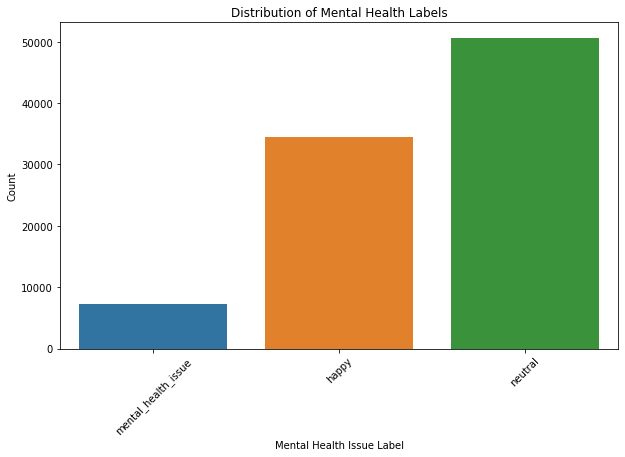

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of labels
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='label')
plt.title("Distribution of Mental Health Labels")
plt.xlabel("Mental Health Issue Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

**Insights:**

 The chart shows three categories with varying frequencies. Neutral category (the green bar) has the highest count, followed by the happy/positive category (orange bar), and the lowest is the  mental health issue category (blue bar).


**Implications**

some categories are more prevalent in the  dataset e.g Neutral and happy . This could impact model training, as an imbalanced dataset may lead the model to perform better on the majority category and worse on the minority.

We may need to consider balancing techniques, such as oversampling the minority class or using class weights, to ensure that the model performs well across all categories.


**3.2 Histogram showing Post Length Distribution**

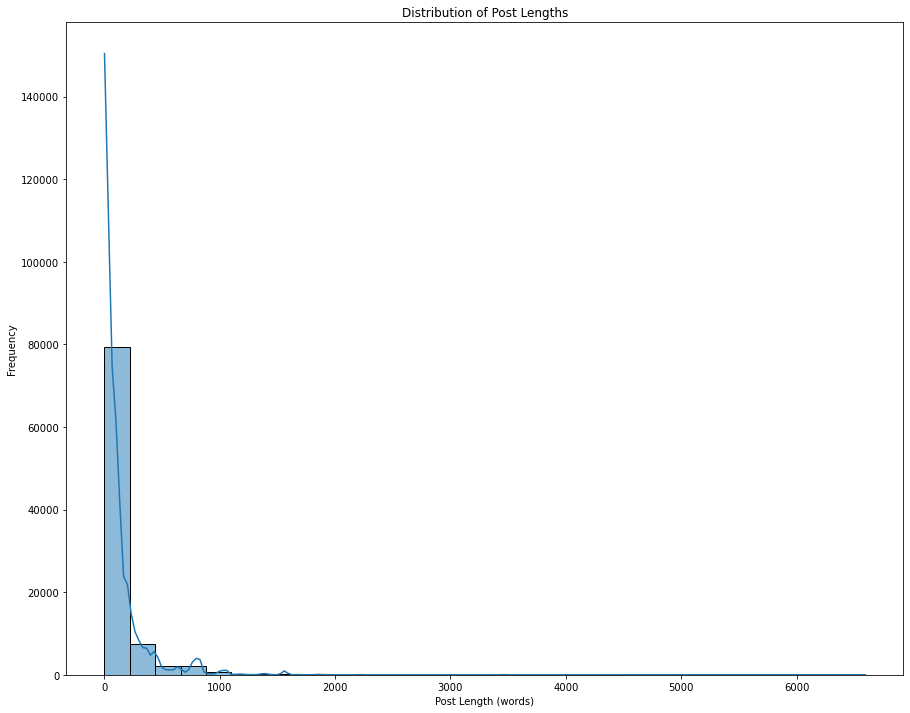

In [12]:
# Calculate the length of each post
data['post_length'] = data['post_body'].apply(lambda x: len(x.split()))

# Plot the distribution of post lengths
plt.figure(figsize=(15, 12))
sns.histplot(data['post_length'], bins=30, kde=True)
plt.title("Distribution of Post Lengths")
plt.xlabel("Post Length (words)")
plt.ylabel("Frequency")
plt.show()

**Insights**

The data is highly skewed to the right, with a large concentration of posts on the left side (lower range).
 This indicates that most posts fall within a lower range  i.e they are shorter than 1000 words , while fewer posts have higher values above 1000 words.

 However, there are some outliers that deviate from the majority  post length and may go up of up to 6,000 words.

 **Implications**

 For modeling, we may handle outliers (very long posts) separately or exclude them if they don't contribute meaningfully to our analysis.

**3.3 Histrogram Showing Distribution of Sentiment Scores**

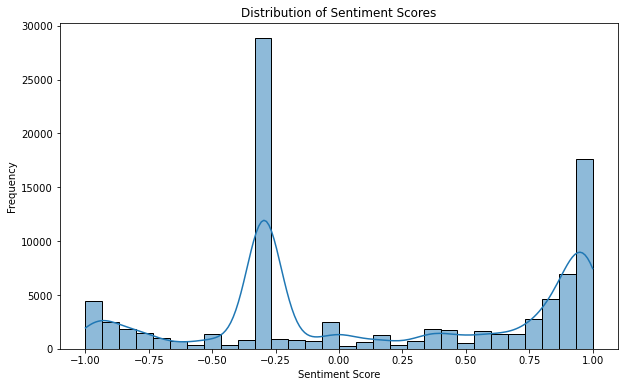

In [16]:

# Initialize the sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Apply VADER sentiment analysis to each post
data['sentiment'] = data['post_body'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

# Plot the sentiment distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['sentiment'], bins=30, kde=True)
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

**Implications**

Thie Histogram seems to show a bimodal distribution with two distinct peaks.

The two prominent peaks indicate that there are two distinct groups within the data. This could imply two different populations or behaviors within the dataset.

The first peak represents one group whose sentiment score is centered around  -0.25 (fairly negative)  while the second peak represents a differenet  group whose sentiment score is centered around 1(very postive).

Both ends of the histogram show smaller bars, which could represent outliers or infrequent behaviors not fitting into the main clusters.

**Implications**

Given the clear separation between the two peaks, it may be beneficial to treat the two groups separately in our analysis.

This segmentation could allow for more targeted insights or better model performance, especially if the behaviors or language used in each group differ.


Modeling Considerations:

A single model may not capture the nuances across both clusters effectively. We may need to consider building separate models or using clustering techniques to handle each group independently.

**3.4 CO-ORELATION MATRIX FOR NUMERICAL FEATURES**

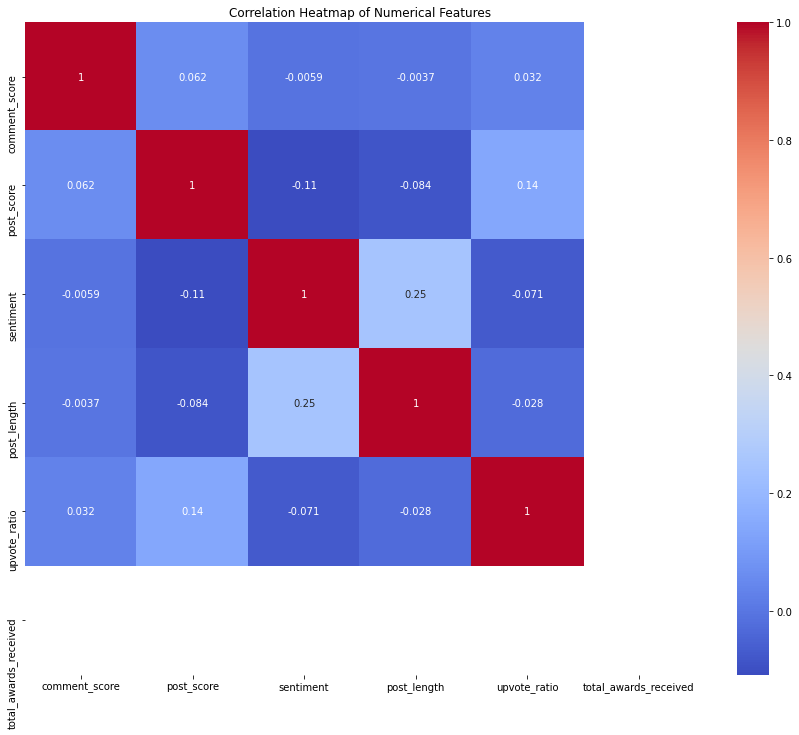

In [17]:
# Selecting numerical features for correlation analysis
numerical_features = ['comment_score', 'post_score', 'sentiment', 'post_length', 'upvote_ratio','total_awards_received','all_awardings']

# Plot the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(data[numerical_features].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

**4.0 DATA PREPROCESSING**

To prepare the text data for modeling, WEtake the following steps:

Converts text to lowercase.

Removes mentions (e.g., @username).

Removes non-alphabetic characters and symbols.

Splits text into words (tokenization).

Removes stop words.

Applies stemming to reduce words to their root form.

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Ensure you have downloaded the necessary NLTK resources
nltk.download('stopwords')
nltk.download('punkt')

# Initialize stemmer and stop words
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove mentions (e.g., @username)
    text = re.sub(r'@\w+', '', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove non-alphabetic characters and symbols
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenize
    words = word_tokenize(text)
    
    # Remove stop words and apply stemming
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    
    # Join words back into a single string
    processed_text = ' '.join(words)
    
    return processed_text

# Applying the function to both 'post_body' and 'comment_body' columns
data['cleaned_post_body'] = data['post_body'].apply(lambda x: preprocess_text(str(x)))
data['cleaned_comment_body'] = data['comment_body'].apply(lambda x: preprocess_text(str(x)))

# Display a sample of the processed data
data.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


                                           post_body  \
0  I'm finding it really hard to keep myself toge...   
1  Please tell me if I sound entitled or selfish....   
2  Does anyone else ever get like this? Or have a...   
3  Does anyone else ever get like this? Or have a...   
4  I feel in over my head and I’m not sure what t...   

                                   cleaned_post_body  \
0  im find realli hard keep togeth everi littl in...   
1  pleas tell sound entitl selfish went worst cri...   
2  anyon els ever get like advic work past year i...   
3  anyon els ever get like advic work past year i...   
4  feel head im sure need object perspect first s...   

                                        comment_body  \
0  Have you got a therapist on board? Sounds like...   
1  I think it’s a combination of factors, and I s...   
2  When I have a panic attack, I tend to think th...   
3  Im wondering if it was simply a panic attack. ...   
4  Please consider seeing a psychologist. Good

In [14]:
#view first 5 rows
data.head()

,title,post_body,comment_body,comment_score,post_url,created,subreddit,label,post_score,post_num_comments,...,all_awardings,num_crossposts,total_awards_received,post_thumbnail,link_flair_text,post_id,comment_id,post_length,cleaned_post_body,cleaned_comment_body
0,I don't know what's wrong with me,I'm finding it really hard to keep myself toge...,Have you got a therapist on board? Sounds like...,2,https://www.reddit.com/r/mentalhealth/comments...,1.730484e+09,mentalhealth,mental_health_issue,1,1,...,[],0,0,self,Venting,1ghb2bs,luw5fgj,156,im find realli hard keep togeth everi littl in...,got therapist board sound like much hold think...
1,Friends who distance themselves from you or cu...,Please tell me if I sound entitled or selfish....,"I think it’s a combination of factors, and I s...",2,https://www.reddit.com/r/mentalhealth/comments...,1.730480e+09,mentalhealth,mental_health_issue,1,1,...,[],0,0,self,Venting,1gh9prb,luvspbv,125,pleas tell sound entitl selfish went worst cri...,think combin factor say someon recent cut tie ...
2,sometimes my brain just keeps telling me bad t...,Does anyone else ever get like this? Or have a...,"When I have a panic attack, I tend to think th...",1,https://www.reddit.com/r/mentalhealth/comments...,1.730486e+09,mentalhealth,mental_health_issue,2,2,...,[],0,0,self,Venting,1gh98yg,luwcwu7,360,anyon els ever get like advic work past year i...,panic attack tend think way bad thing true
3,sometimes my brain just keeps telling me bad t...,Does anyone else ever get like this? Or have a...,Im wondering if it was simply a panic attack. ...,2,https://www.reddit.com/r/mentalhealth/comments...,1.730487e+09,mentalhealth,mental_health_issue,2,2,...,[],0,0,self,Venting,1gh98yg,luwep2n,360,anyon els ever get like advic work past year i...,im wonder simpli panic attack havent type pani...
4,Need objective support. I’m in over my head,I feel in over my head and I’m not sure what t...,Please consider seeing a psychologist. Good luck!,1,https://www.reddit.com/r/mentalhealth/comments...,1.730477e+09,mentalhealth,mental_health_issue,1,4,...,[],0,0,self,Need Support,1gh8q6w,luvir86,422,feel head im sure need object perspect first s...,pleas consid see psychologist good luck


**VISUALIZING COMMON WORDS FOR HAPPY, NEUTRAL AND MENTAL HEALTH SENTIMENTS**

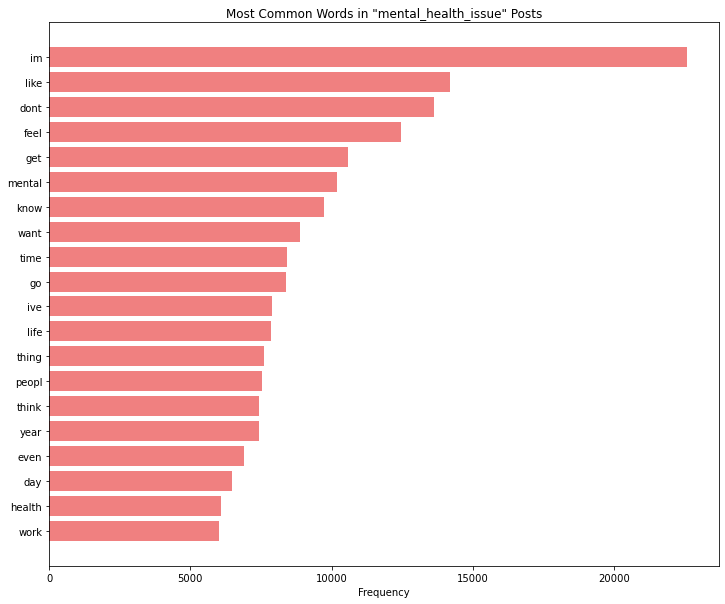

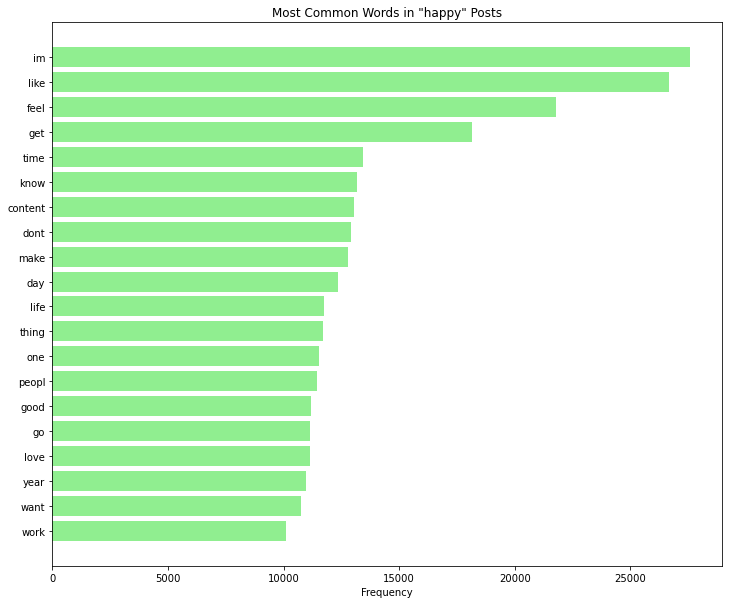

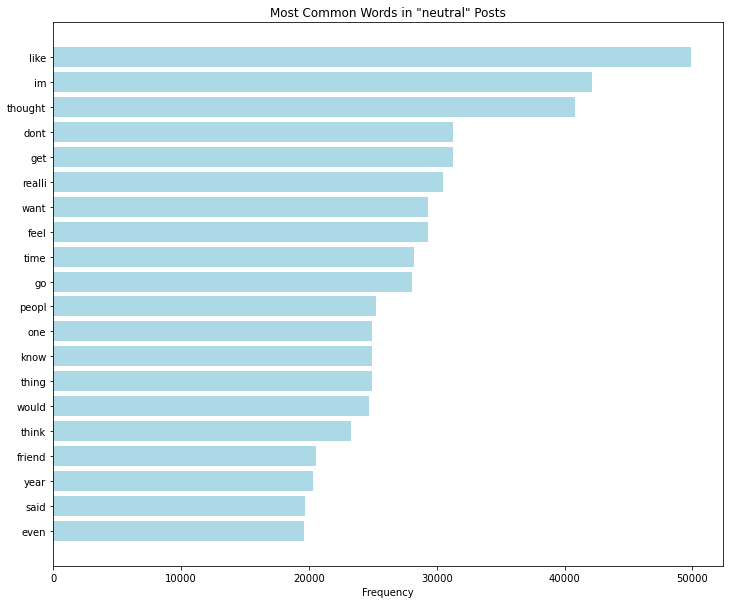

In [15]:
from collections import Counter
import matplotlib.pyplot as plt

# Function to combine text from two columns and generate a common words plot for a specific label
def plot_common_words(data, label_column, label_value, text_column1, text_column2, top_n=20, color='skyblue'):
    # Filter data by the specified label
    label_data = data[data[label_column] == label_value]
    
    # Combine text from both columns
    words = []
    for text in label_data[text_column1].dropna():
        words.extend(text.split())
    for text in label_data[text_column2].dropna():
        words.extend(text.split())
    
    # Count the most common words
    common_words = Counter(words).most_common(top_n)
    
    # Split into words and counts for plotting
    words, counts = zip(*common_words)
    
    # Plot the most common words
    plt.figure(figsize=(12, 10))
    plt.barh(words, counts, color=color)
    plt.xlabel('Frequency')
    plt.title(f'Most Common Words in "{label_value}" Posts')
    plt.gca().invert_yaxis()  # Invert y-axis for better readability
    plt.show()

# usage with different colors for each label
plot_common_words(data, 'label', 'mental_health_issue', 'cleaned_post_body', 'cleaned_comment_body', color='lightcoral')
plot_common_words(data, 'label', 'happy', 'cleaned_post_body', 'cleaned_comment_body', color='lightgreen')
plot_common_words(data, 'label', 'neutral', 'cleaned_post_body', 'cleaned_comment_body', color='lightblue')

**Insights**

The most frequent words can give insights into the primary themes or topics that users discuss in posts labeled as "mental health issues." This can help identify common concerns, challenges, or emotional states shared by users within this category. these words include :feel, mental, health, life, work.

This may imply that majority of mental health issues revolve aroung work , health  and general life concerns.

Terms that appear frequently in mental health-related posts can help the model identify patterns and predict similar issues in new posts.



**COMMON WORDS IN CLEANED POST BODY PER LABEL**

In [27]:
pip install wordcloud


Note: you may need to restart the kernel to use updated packages.


In [ ]:


from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Function to generate and plot word clouds for 'cleaned_post_body' per label
def plot_wordcloud_post_body(data, label):
    # Filter text for the specified label
    text = " ".join(data[data['label'] == label]['cleaned_post_body'])
    
    # Generate the word cloud with a TrueType font
    wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100,
                          font_path="C:/Windows/Fonts/Arial.ttf").generate(text)  # Update this path as needed
    
    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Common Words in 'cleaned_post_body' for Label: {label}")
    plt.show()

# Generate word clouds for each label in 'cleaned_post_body'
for label in data['label'].unique():
    plot_wordcloud_post_body(data, label)




**FEARURE SELECTION**

In [17]:
from sklearn.preprocessing import LabelEncoder

# Select relevant columns for modeling and create a copy
selected_columns = [
    'cleaned_post_body', 'cleaned_comment_body', 'subreddit',
    'post_score', 'comment_score', 'upvote_ratio', 'post_flair', 'label'
]
data = data[selected_columns].copy()  # Create a copy to avoid SettingWithCopyWarning

# Initialize the label encoder
label_encoder = LabelEncoder()

# Label encode the target column 'label'
data.loc[:, 'label_encoded'] = label_encoder.fit_transform(data['label'])

# Optional: Encode additional categorical columns like 'subreddit' or 'post_flair'
data.loc[:, 'subreddit_encoded'] = label_encoder.fit_transform(data['subreddit'])
data.loc[:, 'post_flair_encoded'] = label_encoder.fit_transform(data['post_flair'].astype(str))

# Drop the original columns if you’re done encoding them
data.drop(columns=['label', 'subreddit', 'post_flair'], inplace=True)

# Display the processed data
print(data.head())


                                   cleaned_post_body  \
0  im find realli hard keep togeth everi littl in...   
1  pleas tell sound entitl selfish went worst cri...   
2  anyon els ever get like advic work past year i...   
3  anyon els ever get like advic work past year i...   
4  feel head im sure need object perspect first s...   

                                cleaned_comment_body  post_score  \
0  got therapist board sound like much hold think...           1   
1  think combin factor say someon recent cut tie ...           1   
2         panic attack tend think way bad thing true           2   
3  im wonder simpli panic attack havent type pani...           2   
4            pleas consid see psychologist good luck           1   

   comment_score  upvote_ratio  label_encoded  subreddit_encoded  \
0              2           1.0              1                 13   
1              2           1.0              1                 13   
2              1           1.0              1     

**SPLITTING THE DATASET**

In [18]:
from sklearn.model_selection import train_test_split

# Define features and target variable
X = data.drop(columns=['label_encoded'])  # Features
y = data['label_encoded']  # Target variable

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Display shapes of the training and test sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (73916, 7)
X_test shape: (18479, 7)
y_train shape: (73916,)
y_test shape: (18479,)


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# combined text feature without modifying original DataFrames
X_train_combined = X_train['cleaned_post_body'] + ' ' + X_train['cleaned_comment_body']
X_test_combined = X_test['cleaned_post_body'] + ' ' + X_test['cleaned_comment_body']


# Define pipeline
logreg_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),  # Vectorize combined text
    ('clf', LogisticRegression(max_iter=200))
])

# 5. Train the model
logreg_pipeline.fit(X_train_combined, y_train)

c:\Users\PC\anaconda3\envs\learn-env\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=5000)),
                ('clf', LogisticRegression(max_iter=200))])